In [1]:
import pandas as pd

from fetch_datasets import fetch_datasets
from preprocess_datasets import preprocess
from data_splitting import data_splitting
from model import solar_predictor_model
from train import train_my_model

from dataset import SolarDataset
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt
import seaborn as sns


#first step is to fetch the datasets and save them
fetch_datasets()

data_chester = pd.read_csv(f'./data_chester.csv')
data_chester.head()


/Users/benji/Documents/dissertation/python_environment/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


CSV created successfully with shape: (26280, 12)
CSV created successfully with shape: (26280, 12)


,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.0,0.0,13.22,90.0,99.38,86.68,11.24,3.57
1,2023,1,1,1,0.0,0.0,0.03,90.0,99.36,88.75,10.80,3.57
2,2023,1,1,2,0.0,0.0,2.10,90.0,99.35,91.08,10.39,3.58
3,2023,1,1,3,0.0,0.0,4.17,90.0,99.36,92.55,10.11,3.59
4,2023,1,1,4,0.0,0.0,18.84,90.0,99.37,92.74,10.06,3.79


In [2]:
data_lagos = pd.read_csv(f'./data_lagos.csv')
data_lagos.head()

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.0,0.0,0.31,90.0,92.65,84.71,18.57,0.71
1,2023,1,1,1,0.0,0.0,6.56,90.0,92.58,85.04,18.01,0.70
2,2023,1,1,2,0.0,0.0,0.62,90.0,92.52,85.36,17.47,0.71
3,2023,1,1,3,0.0,0.0,1.23,90.0,92.49,85.49,17.00,0.70
4,2023,1,1,4,0.0,0.0,0.93,90.0,92.49,86.27,16.46,0.65


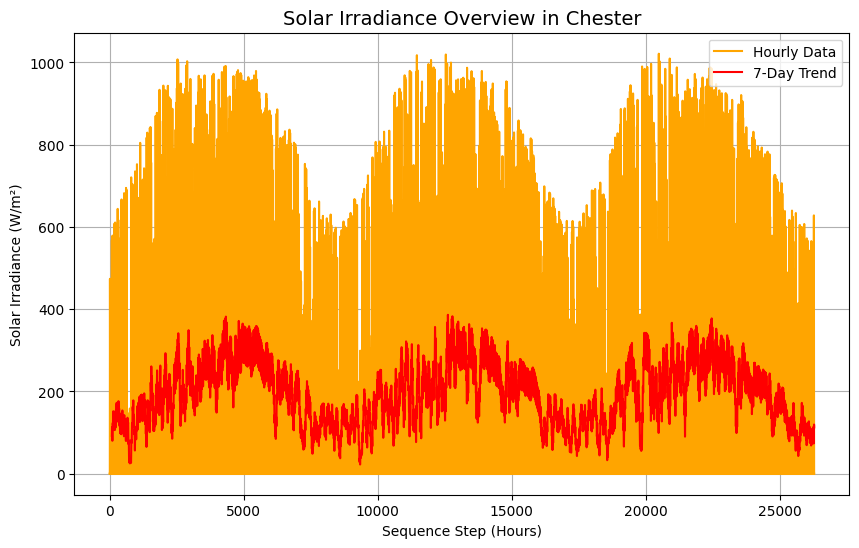

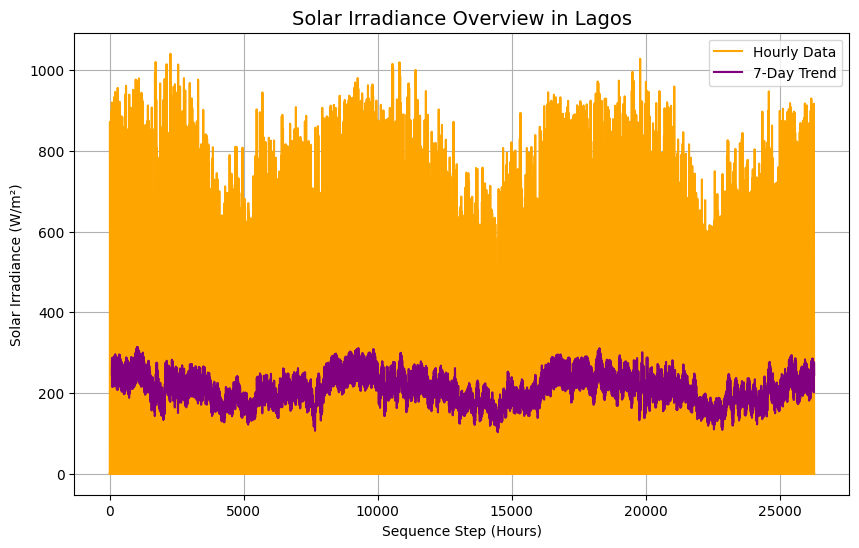

In [3]:
target_col = 'ALLSKY_SFC_SW_DWN' # This is the column we want to visualize

plt.figure(figsize=(10, 6))
plt.plot(data_chester[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_chester[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(data_lagos[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_lagos[target_col].rolling(window=84).mean(), color='purple', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()

In [4]:

#second step is to preprocess the datasets and save them
preprocess(data_chester, data_lagos)

preprocessed_data_chester = pd.read_csv(f'./preprocessed_chester.csv')
preprocessed_data_lagos = pd.read_csv(f'./preprocessed_lagos.csv')


In [5]:
# Load the preprocessed data for Chester
preprocessed_data_chester.head()

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.0,0.0,0.1322,1.0,0.413306,0.848997,0.399536,0.363169,0.000000,1.000000,1,0.017202,0.999852
1,2023,1,1,1,0.0,0.0,0.0003,1.0,0.409274,0.872463,0.391685,0.363169,0.258819,0.965926,1,0.017202,0.999852
2,2023,1,1,2,0.0,0.0,0.0210,1.0,0.407258,0.898878,0.384368,0.364198,0.500000,0.866025,1,0.017202,0.999852
3,2023,1,1,3,0.0,0.0,0.0417,1.0,0.409274,0.915542,0.379372,0.365226,0.707107,0.707107,1,0.017202,0.999852
4,2023,1,1,4,0.0,0.0,0.1884,1.0,0.411290,0.917696,0.378480,0.385802,0.866025,0.500000,1,0.017202,0.999852


In [6]:
# Load the preprocessed data for Lagos
preprocessed_data_lagos.head()

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.0,0.0,0.0031,1.0,0.642276,0.810767,0.227230,0.384615,0.000000,1.000000,1,0.017202,0.999852
1,2023,1,1,1,0.0,0.0,0.0656,1.0,0.585366,0.814851,0.200664,0.379121,0.258819,0.965926,1,0.017202,0.999852
2,2023,1,1,2,0.0,0.0,0.0062,1.0,0.536585,0.818812,0.175047,0.384615,0.500000,0.866025,1,0.017202,0.999852
3,2023,1,1,3,0.0,0.0,0.0123,1.0,0.512195,0.820421,0.152751,0.379121,0.707107,0.707107,1,0.017202,0.999852
4,2023,1,1,4,0.0,0.0,0.0093,1.0,0.512195,0.830074,0.127135,0.351648,0.866025,0.500000,1,0.017202,0.999852


Target column starts at index: 26256


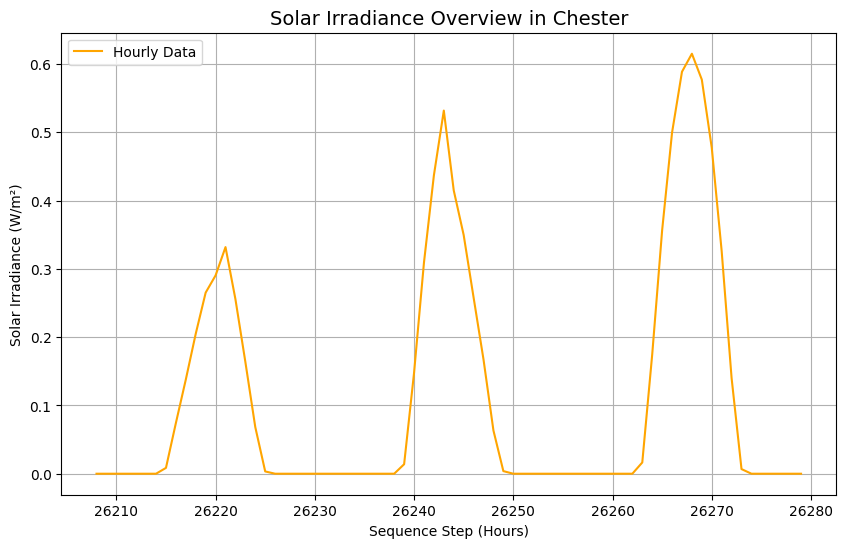

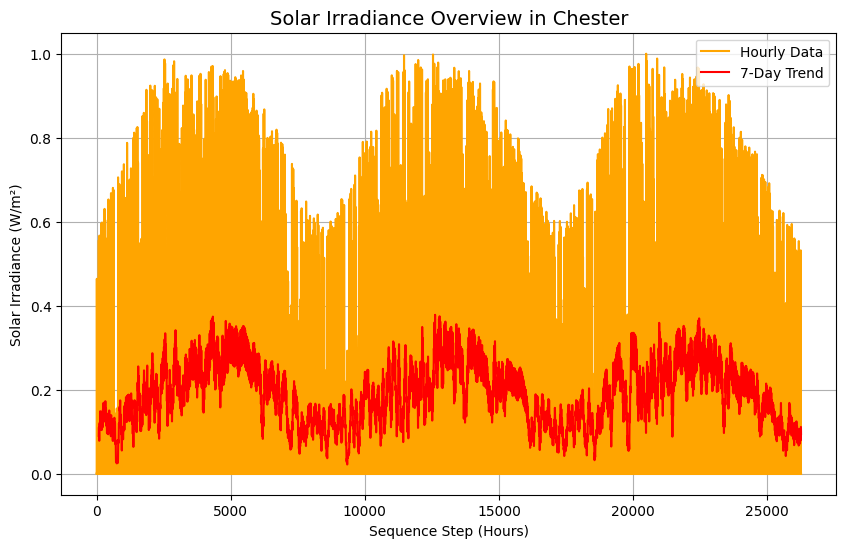

,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.0,0.1322,1.0,0.399536,0.848997,0.413306,0.363169,0.000000,1.000000,0.017202,0.999852
1,0.0,0.0003,1.0,0.391685,0.872463,0.409274,0.363169,0.258819,0.965926,0.017202,0.999852
2,0.0,0.0210,1.0,0.384368,0.898878,0.407258,0.364198,0.500000,0.866025,0.017202,0.999852
3,0.0,0.0417,1.0,0.379372,0.915542,0.409274,0.365226,0.707107,0.707107,0.017202,0.999852
4,0.0,0.1884,1.0,0.378480,0.917696,0.411290,0.385802,0.866025,0.500000,0.017202,0.999852


In [7]:
# Split the preprocessed data into training and testing sets

chester_train, chester_test, lagos_train, lagos_test, id = data_splitting(preprocessed_data_chester, preprocessed_data_lagos)
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(chester_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(chester_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(chester_train[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
chester_train.head()

Target column starts at index: 26256


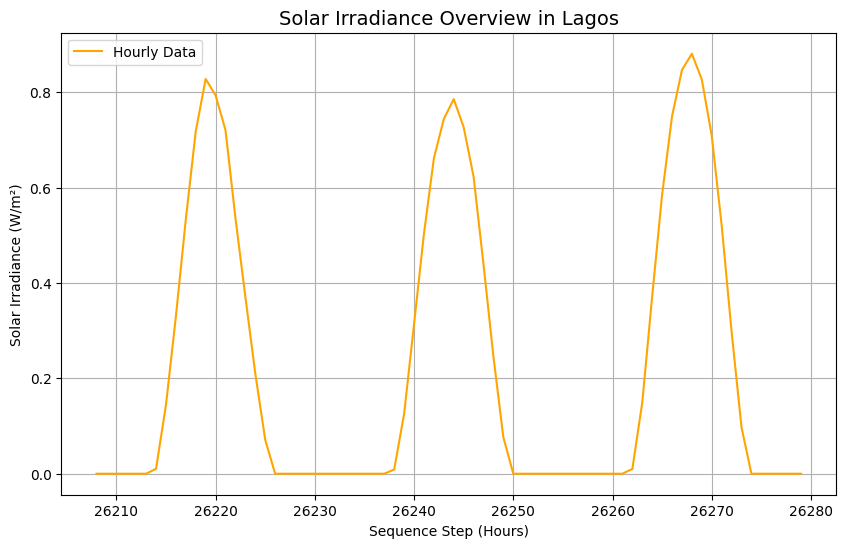

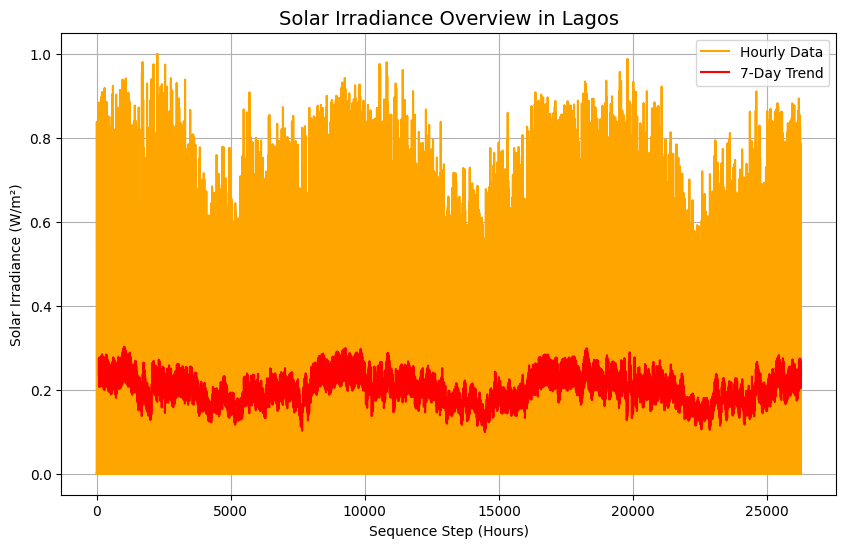

,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.0,0.0031,1.0,0.227230,0.810767,0.642276,0.384615,0.000000,1.000000,0.017202,0.999852
1,0.0,0.0656,1.0,0.200664,0.814851,0.585366,0.379121,0.258819,0.965926,0.017202,0.999852
2,0.0,0.0062,1.0,0.175047,0.818812,0.536585,0.384615,0.500000,0.866025,0.017202,0.999852
3,0.0,0.0123,1.0,0.152751,0.820421,0.512195,0.379121,0.707107,0.707107,0.017202,0.999852
4,0.0,0.0093,1.0,0.127135,0.830074,0.512195,0.351648,0.866025,0.500000,0.017202,0.999852


In [8]:
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(lagos_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(lagos_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(lagos_train[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
lagos_train.head()

In [9]:
# Create the Dataset objects for both cities
# This uses the data frames returned by your data_splitting function


chester_ds = SolarDataset(chester_train, window=48, forecast=24)


# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
chester_loader = DataLoader(chester_ds, batch_size=32, shuffle=False, drop_last=True)


In [10]:
# next(iter(...)) pulls the very first 'tray' off the conveyor belt
train_x, train_y = next(iter(chester_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")   # Should be [32, 48, 11]

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}")  # Should be [32, 24]

# Let's check a single value to make sure it's normalized (between 0 and 1)
print(f"First value of first batch: {train_x[1,1,0].item()}")

Input Shape: torch.Size([32, 48, 11])
Target Shape: torch.Size([32, 24])
First value of first batch: 0.0


In [11]:
# 1. Train LSTM for Chester
lstm_chester = solar_predictor_model(11, 64, model_type='LSTM')
train_my_model(lstm_chester, chester_loader)


Starting Training for LSTM...
Epoch [10/50], Loss: 0.008069
Epoch [20/50], Loss: 0.007701
Epoch [30/50], Loss: 0.007473
Epoch [40/50], Loss: 0.007194
Epoch [50/50], Loss: 0.007028
Training Complete!


In [12]:
# # 2. Train GRU for Chester
# gru_chester = solar_predictor_model(11, 64, model_type='GRU')
# train_my_model(gru_chester, chester_loader)


In [13]:
import numpy as np
import torch

# 2. Use .values to avoid the KeyError
# This turns the "Dec 30th" slice into a clean matrix starting at index 0
# Change window_in to window and window_out to forecast
print(len(chester_test))  # Check the column names to confirm
chester_ds_test = SolarDataset(chester_test, window=48, forecast=24)
# 3. Create the loader
chester_test_loader = DataLoader(chester_ds_test, batch_size=32, shuffle=False)

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            preds = model(x_batch)
            all_preds.append(preds.numpy())
            all_actuals.append(y_batch.numpy())
            
    return np.concatenate(all_preds), np.concatenate(all_actuals)


# Save the preprocessed datasets
chester_test.to_csv("test_chester.csv", index=False)
# Get predictions for both
lstm_preds, actuals = evaluate_model(lstm_chester, chester_test_loader)
# gru_preds, _ = evaluate_model(gru_chester, chester_test_loader)
chester_test.head()


72


,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
26208,0.0,0.2639,1.0,0.524982,0.958168,0.393145,0.411523,0.000000,1.000000,-0.055879,0.998438
26209,0.0,0.8833,1.0,0.521413,0.970185,0.393145,0.414609,0.258819,0.965926,-0.055879,0.998438
26210,0.0,0.8183,1.0,0.514276,0.997506,0.393145,0.387860,0.500000,0.866025,-0.055879,0.998438
26211,0.0,0.6372,1.0,0.512670,1.000000,0.399194,0.372428,0.707107,0.707107,-0.055879,0.998438
26212,0.0,0.4505,1.0,0.512848,0.996146,0.409274,0.361111,0.866025,0.500000,-0.055879,0.998438


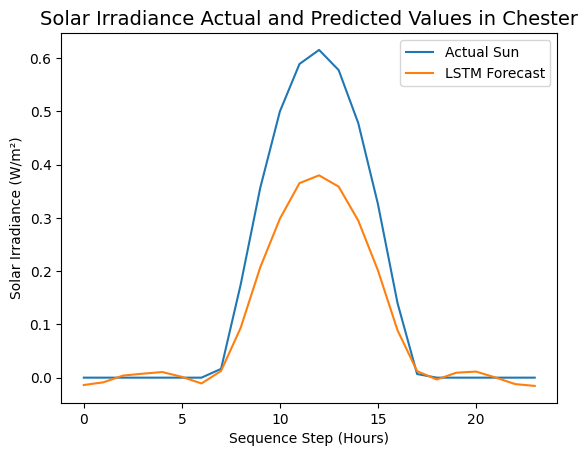

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.0164819  0.17454363 0.35635382 0.49952993 0.5886478
 0.6150893  0.57716036 0.47756386 0.3261321  0.1401892  0.00678667
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-1.3791427e-02 -8.7148771e-03  3.9114356e-03  7.4335337e-03
  1.0556966e-02  1.5336275e-03 -1.0872930e-02  1.2581453e-02
  9.3497552e-02  2.0715967e-01  2.9814029e-01  3.6503312e-01
  3.7970316e-01  3.5845634e-01  2.9466394e-01  2.0153347e-01
  8.9064151e-02  1.2227282e-02 -3.5114586e-03  9.2655569e-03
  1.1406064e-02  2.8198957e-04 -1.2070134e-02 -1.5519828e-02]


In [14]:
# To see your December 30th forecast:
import matplotlib.pyplot as plt
plt.plot(actuals[0], label='Actual Sun')
plt.plot(lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", actuals[0])
print("LSTM predictions for the first test window:", lstm_preds[0])

In [15]:
# # To see your December 30th forecast:
# import matplotlib.pyplot as plt
# plt.plot(actuals[0], label='Actual Sun')
# plt.plot(gru_preds[0], label='GRU Forecast')
# plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
# plt.xlabel('Sequence Step (Hours)')
# plt.ylabel('Solar Irradiance (W/m²)')
# plt.legend()
# plt.show()
# print("Actual values for the first test window:", actuals[0])
# print("GRU predictions for the first test window:", gru_preds[0])

In [16]:
# # To see your December 30th forecast:
# import matplotlib.pyplot as plt
# plt.plot(actuals[0], label='Actual Sun')
# plt.plot(lstm_preds[0], label='LSTM Forecast')
# plt.plot(gru_preds[0], label='GRU Forecast')
# plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
# plt.xlabel('Sequence Step (Hours)')
# plt.ylabel('Solar Irradiance (W/m²)')
# plt.legend()
# plt.show()
# print("Actual values for the first test window:", actuals[0])
# print("RNN models predictions for the first test window:", lstm_preds[0])

In [17]:
####Lagos DS

In [18]:
# Create the Dataset objects for both cities
# This uses the data frames returned by your data_splitting function

lagos_ds = SolarDataset(lagos_train, window=48, forecast=24)


# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
lagos_loader = DataLoader(lagos_ds, batch_size=32, shuffle=True, drop_last=True)

In [19]:
# next(iter(...)) pulls the very first 'tray' off the conveyor belt
train_x, train_y = next(iter(chester_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")   # Should be [32, 48, 11]

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}")  # Should be [32, 24]

# Let's check a single value to make sure it's normalized (between 0 and 1)
print(f"First value of first batch: {train_x[1,1,0].item()}")

Input Shape: torch.Size([32, 48, 11])
Target Shape: torch.Size([32, 24])
First value of first batch: 0.0


In [20]:

#train lstm
lstm_lagos = solar_predictor_model(11, 64, model_type='LSTM')
train_my_model(lstm_lagos, lagos_loader)

Starting Training for LSTM...
Epoch [10/50], Loss: 0.003334
Epoch [20/50], Loss: 0.002948
Epoch [30/50], Loss: 0.002012
Epoch [40/50], Loss: 0.001205
Epoch [50/50], Loss: 0.000837
Training Complete!


In [21]:

# # Repeat for GRU
# gru_lagos = solar_predictor_model(11, 64, model_type='GRU')
# train_my_model(gru_lagos, lagos_loader)

In [27]:
import numpy as np
import torch

# 2. Use .values to avoid the KeyError
# This turns the "Dec 30th" slice into a clean matrix starting at index 0
# Change window_in to window and window_out to forecast
print(len(lagos_test))  # Check the column names to confirm
lagos_ds_test = SolarDataset(lagos_test, window=48, forecast=24)
# 3. Create the loader
lagos_test_loader = DataLoader(lagos_ds_test, batch_size=32, shuffle=False)

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            preds = model(x_batch)
            all_preds.append(preds.numpy())
            all_actuals.append(y_batch.numpy())
            
    return np.concatenate(all_preds), np.concatenate(all_actuals)


# Save the preprocessed datasets
lagos_test.to_csv("test_lagos.csv", index=False)
# Get predictions for both
lagos_lstm_preds, actuals = evaluate_model(lstm_lagos, lagos_test_loader)
# gru_preds, _ = evaluate_model(gru_lagos, lagos_test_loader)
lagos_test.head()

72


,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
26208,0.0,0.0370,1.0,0.272296,0.984035,0.577236,0.181319,0.000000,1.000000,-0.055879,0.998438
26209,0.0,0.4701,1.0,0.265180,0.969183,0.536585,0.186813,0.258819,0.965926,-0.055879,0.998438
26210,0.0,0.3512,1.0,0.258539,0.952475,0.504065,0.192308,0.500000,0.866025,-0.055879,0.998438
26211,0.0,0.4592,1.0,0.248102,0.938985,0.487805,0.192308,0.707107,0.707107,-0.055879,0.998438
26212,0.0,0.3589,1.0,0.232448,0.935272,0.504065,0.186813,0.866025,0.500000,-0.055879,0.998438


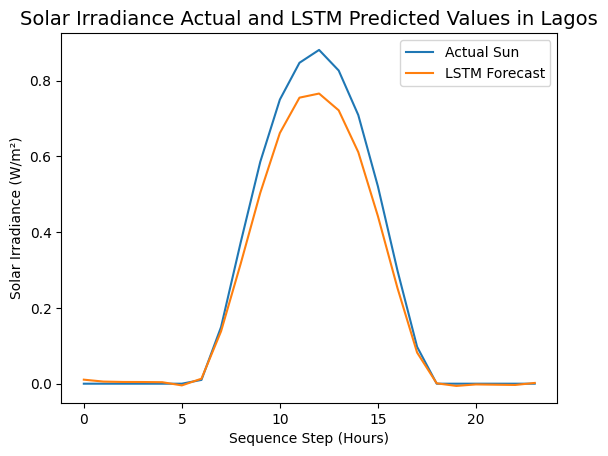

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.01002018 0.14953406 0.3725622  0.5855029  0.7497838  0.8468921
 0.88082427 0.8264963  0.70892495 0.5209434  0.29831877 0.09727159
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [ 0.01063465  0.00559141  0.00458945  0.0044346   0.00394328 -0.00449149
  0.01320842  0.13824078  0.3164656   0.5036648   0.6615846   0.75485766
  0.7657032   0.7214534   0.6110138   0.4422602   0.25218627  0.08220153
  0.00099235 -0.00586858 -0.00190572 -0.00264998 -0.00333152  0.00199852]


In [28]:
# To see your December 30th forecast:
import matplotlib.pyplot as plt
plt.plot(actuals[0], label='Actual Sun')
plt.plot(lagos_lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and LSTM Predicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", actuals[0])
print("LSTM predictions for the first test window:", lstm_preds[0])

In [24]:
# # To see your December 30th forecast:
# import matplotlib.pyplot as plt
# plt.plot(actuals[0], label='Actual Sun')
# plt.plot(gru_preds[0], label='GRU Forecast')
# plt.title('Solar Irradiance Actual and GRUPredicted Values in Chester', fontsize=14)
# plt.xlabel('Sequence Step (Hours)')
# plt.ylabel('Solar Irradiance (W/m²)')
# plt.legend()
# plt.show()
# print("Actual values for the first test window:", actuals[0])
# print("GRU predictions for the first test window:", gru_preds[0])

In [25]:
# # To see your December 30th forecast:
# import matplotlib.pyplot as plt
# plt.plot(actuals[0], label='Actual Sun')
# plt.plot(lstm_preds[0], label='LSTM Forecast')
# plt.plot(gru_preds[0], label='GRU Forecast')
# plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
# plt.xlabel('Sequence Step (Hours)')
# plt.ylabel('Solar Irradiance (W/m²)')
# plt.legend()
# plt.show()
# print("Actual values for the first test window:", actuals[0])
# print("LSTM predictions for the first test window:", lstm_preds[0])